# **Earthquake Analysis**
## *Hypothesis testing Notebook* 


## Objectives

* Hypotheses testing

* Use Machine Learning to test prediction of high severity events


## Inputs

* The cleaned 'earthquake_1995-2023_cleaned.csv'

* Libraries containing the tools needed. Pandas, numpy, matplotlib , seaborn, scipy and sk-learn.

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Earthquake_Analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Earthquake_Analysis'

# Import block

These are the libraries required to process and inspect the data. 


In [4]:
# Librairies and modules needed to perform analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler



And load the .csv to a dataframe 

In [5]:
# .csv to dataframe
df_clean = pd.read_csv("Dataset/Cleaned/earthquake_1995-2023_cleaned.csv")

# View the dataframe
df_clean.head(10)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,...,continent,country,mag_depth_interaction,depth_cat,is_off_shore,high,high_severity,year,month,hour
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,...,off_shore,Vanuatu,1254.21,Intermediate,False,0,0,2023,8,12
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,...,off_shore,off_shore,453.23,shallow,True,0,0,2023,7,0
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,...,South America,Argentina,1131.05,Intermediate,False,1,1,2023,7,3
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,...,off_shore,off_shore,234.51,shallow,True,0,0,2023,7,6
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,unassigned,1,820,at,79,...,off_shore,off_shore,153.30,shallow,True,0,0,2023,7,6
5,"M 6.6 - 277 km NNE of Codrington, Antigua and ...",6.6,2023-07-10 20:28:00,5,4,green,1,802,us,95,...,off_shore,off_shore,66.00,shallow,True,0,0,2023,7,20
6,M 6.9 - Tonga,6.9,2023-07-02 10:27:00,4,4,green,1,741,us,136,...,off_shore,off_shore,1580.10,Intermediate,True,0,0,2023,7,10
7,M 7.2 - south of the Fiji Islands,7.2,2023-06-15 18:06:00,8,6,green,1,804,us,85,...,off_shore,off_shore,1205.31,Intermediate,True,0,0,2023,6,18
8,M 6.6 - Panama-Colombia border region,6.6,2023-05-25 03:05:00,6,6,green,1,733,us,50,...,off_shore,Colombia,66.00,shallow,False,0,0,2023,5,3
9,M 7.1 - southeast of the Loyalty Islands,7.1,2023-05-20 01:51:00,3,4,green,1,777,us,98,...,off_shore,off_shore,255.47,shallow,True,0,0,2023,5,1


---

# Section 2 - Testing H1


To test whether earthquake magnitude is independent of depth, we evaluate both linear and non-linear relationships. Because depth exhibits heavy right skewness, we calculate both Pearson Correlation and Spearman Rank Correlation to compare linear trends against monotonic trends.

In [6]:
# Pearson (linear) vs Spearman (rank/monotonic) correlation
pearson_corr = df_clean["magnitude"].corr(df_clean["depth"], method="pearson")
spearman_corr = df_clean["magnitude"].corr(df_clean["depth"], method="spearman")

print(f"Pearson Correlation (Magnitude vs Depth):  {pearson_corr:.3f}")
print(f"Spearman Correlation (Magnitude vs Depth): {spearman_corr:.3f}")

Pearson Correlation (Magnitude vs Depth):  0.017
Spearman Correlation (Magnitude vs Depth): 0.096


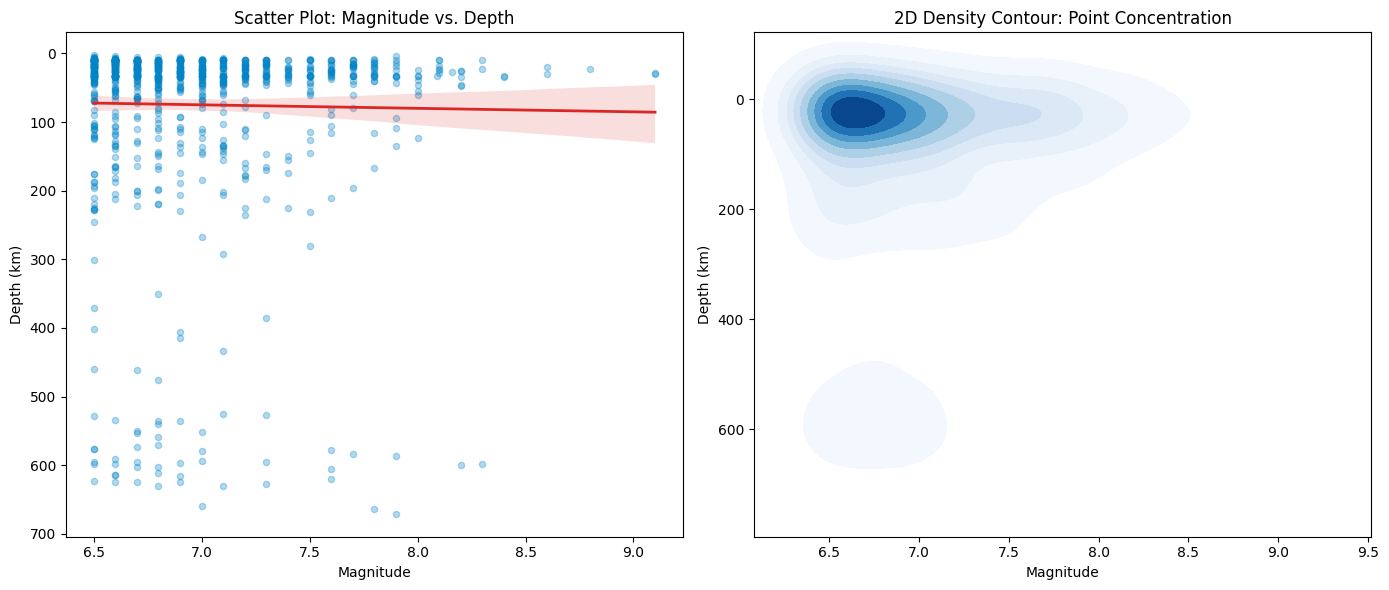

In [13]:
# Ai aided with understanding and formatting 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Scatter Plot with Regression Trendline
sns.regplot(
    data=df_clean,
    x="magnitude",
    y="depth",
    ax=axes[0],
    color="#0284c7",
    scatter_kws={"alpha": 0.3, "s": 20},
    line_kws={"color": "#dc2626", "linewidth": 2},
)
axes[0].set_title("Scatter Plot: Magnitude vs. Depth")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Depth (km)")
axes[0].invert_yaxis()

# 2. 2D KDE Density Contour Plot
sns.kdeplot(
    data=df_clean,
    x="magnitude",
    y="depth",
    ax=axes[1],
    cmap="Blues",
    fill=True,
    thresh=0.05,
)
axes[1].set_title("2D Density Contour: Point Concentration")
axes[1].set_xlabel("Magnitude")
axes[1].set_ylabel("Depth (km)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

The flat regression line and negligible Pearson coefficient, r = 0.017, confirm no linear correlation between magnitude and depth. While the concentration of recorded event depth narrows at higher magnitudes, this reflects general event frequency, extreme magnitude earthquakes are simply rarer overall—rather than a true physical dependency. Additionally, the density contours highlight that the overwhelming majority of recorded events are concentrated in shallow-to-intermediate crustal depths, upto 200km.

---

# Section 3 - Testing H2

We know the low count magnitude types needs to grouped in a single column but let's visualise tsunami against dpeth first.

C:\Users\NateM\AppData\Local\Temp\ipykernel_20092\1111287534.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\NateM\AppData\Local\Temp\ipykernel_20092\1111287534.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Tsunami", "Tsunami"])


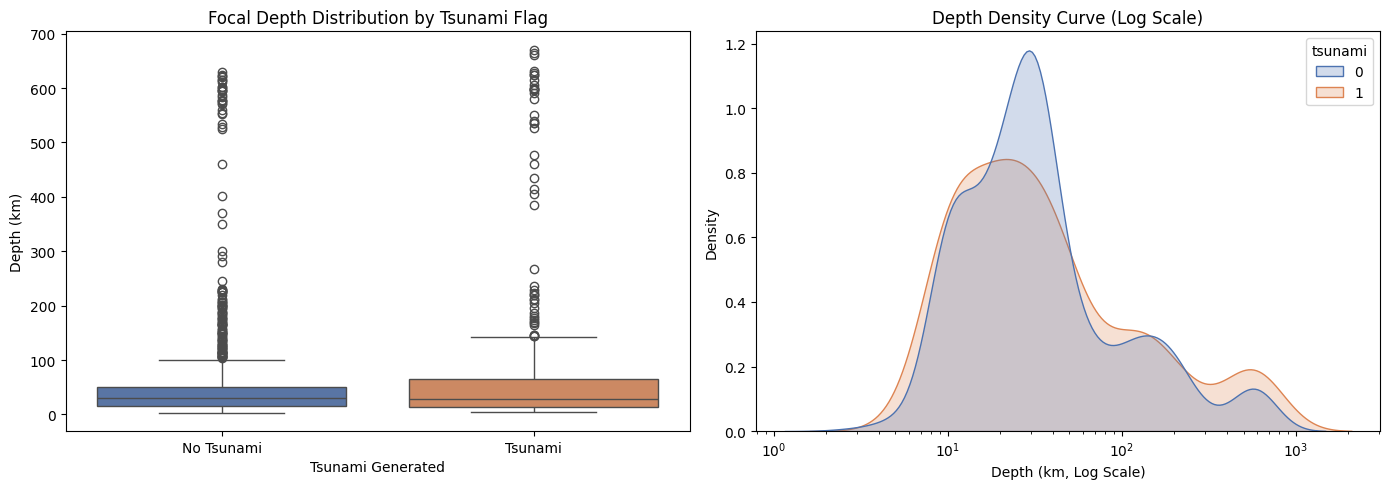

In [8]:
# Create figure layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot (Depth by Tsunami Flag)
# ai made
sns.boxplot(
    data=df_clean,
    x="tsunami",
    y="depth",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[0]
)
axes[0].set_title("Focal Depth Distribution by Tsunami Flag", fontsize=12)
axes[0].set_xlabel("Tsunami Generated")
axes[0].set_ylabel("Depth (km)")
axes[0].set_xticklabels(["No Tsunami", "Tsunami"])

# 2. Log-Scaled KDE Plot (to account for right skew)
sns.kdeplot(
    data=df_clean,
    x="depth",
    hue="tsunami",
    common_norm=False,
    fill=True,
    palette=["#4C72B0", "#DD8452"],
    log_scale=True,
    ax=axes[1]
)
axes[1].set_title("Depth Density Curve (Log Scale)", fontsize=12)
axes[1].set_xlabel("Depth (km, Log Scale)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

Comparative boxplots and log-scale density curves demonstrate that tsunami and non-tsunami events share remarkably similar depth characteristics, making them innately indistinguishable on focal depth alone. Both classes group tightly within the shallow crustal range of 50–70 km—near the Earth's surface crust boundary rather than deeper subduction zones. Because near-identical medians and interquartile ranges exist across both categories, depth alone cannot serve as a decisive indicator of tsunami generation.

Now for the tests.

In [9]:
#ai guideded 
# Making the other group
top_types = ["mww", "mwc", "mwb", "mw"]
df_clean["magType_grouped"] = df_clean["magType"].apply(lambda x: x if x in top_types else "Other")

# Brackets for the Mann-whitney U Test 
tsunami_depths = df_clean[df_clean["tsunami"] == 1]["depth"]
no_tsunami_depths = df_clean[df_clean["tsunami"] == 0]["depth"]

mwu_stat, mwu_p = stats.mannwhitneyu(tsunami_depths, no_tsunami_depths, alternative="two-sided")

# Chi-Squared Test magType - tsunami
contingency_table = pd.crosstab(df_clean["magType_grouped"], df_clean["tsunami"])
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

mwu_p_str = f"{mwu_p:.4f}" if mwu_p >= 0.0001 else "< 0.0001"
chi2_p_str = f"{chi2_p:.4f}" if chi2_p >= 0.0001 else "< 0.0001"

print("H2 Statistical Test Results")
print(f"Mann-Whitney U Test (Depth vs Tsunami): U = {mwu_stat:.2f}, p-value = {mwu_p_str}")
print(f"Median Depth (Tsunami = 1): {tsunami_depths.median():.2f} km")
print(f"Median Depth (Tsunami = 0): {no_tsunami_depths.median():.2f} km")

print(f"\nChi-Square Test (magType vs Tsunami): Chi2 = {chi2_stat:.2f}, p-value = {chi2_p_str}, dof = {dof}")

H2 Statistical Test Results
Mann-Whitney U Test (Depth vs Tsunami): U = 110487.50, p-value = 0.8516
Median Depth (Tsunami = 1): 28.00 km
Median Depth (Tsunami = 0): 30.00 km

Chi-Square Test (magType vs Tsunami): Chi2 = 412.48, p-value = < 0.0001, dof = 4


The tests show that focal depth alone isn't capable of indicating tsunami occurrence, having functionally the same shallow depth median, 28km/30km and a high p-value of 0.8516. The magnitude type in contrast is highly significant in whether a tsunami is triggered with p-value of less than 0.0001. This confirms the specific type of an earthquake is responsible for tsunami generation as apposed to the depth of an earthquake.    

---

# Section 4 - Testing H3

The feature matrix needs to be set up before we can train and test the model. The test split will need to be stratified, meaning our split will preserve the percentage split between servere and non-severe.

In [10]:
# Storing the real-time physical features
fMatrix_columns = ["magnitude", "depth", "latitude", "longitude", "magType"]
# Storing X and y 
X = df_clean[fMatrix_columns].copy()
y = df_clean["high_severity"]

# One-hot Encode magType
X = pd.get_dummies(X, columns=["magType"], drop_first=True)

# Stratify the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Features matrix shape: {X.shape}")
print(f"High Severity positive rate: {y.mean():.2%}")


Features matrix shape: (1000, 12)
High Severity positive rate: 47.50%


The feature matrix is configured. The target distribution of 'high_severity' shows a balanced positive rate of 47.50%, providing a well-balanced target for the model training. 

In [11]:
# Scale features for Logistic Regression baseline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression (Baseline) ---
logistic_regression_model = LogisticRegression(class_weight="balanced", random_state=42)
logistic_regression_model.fit(X_train_scaled, y_train)
logistic_regression_predict = logistic_regression_model.predict(X_test_scaled)

# Model 2: Random Forest (Comparison) ---
random_forest_model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42
)
random_forest_model.fit(X_train, y_train)
random_forest_predict = random_forest_model.predict(X_test)

# Print performance metrics
print("Logistic Regression - Baseline")
print(f"Recall: {recall_score(y_test, logistic_regression_predict):.2%}")
print(classification_report(y_test, logistic_regression_predict))

print("Random Forest - Comparison")
print(f"Recall: {recall_score(y_test, random_forest_predict):.2%}")
print(classification_report(y_test, random_forest_predict))

Logistic Regression - Baseline
Recall: 61.05%
              precision    recall  f1-score   support

           0       0.68      0.75      0.71       105
           1       0.69      0.61      0.65        95

    accuracy                           0.69       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.69      0.69      0.68       200

Random Forest - Comparison
Recall: 76.84%
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       105
           1       0.78      0.77      0.77        95

    accuracy                           0.79       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.79      0.78       200



The classification report shows that the Logistic Regression baseline struggles to map the datasets non linear boundaries for the localised intensity, producing a Recall of 61.05%, F1 score of 0.65 and an Accuracy of 68.50% (unrounded). 

Compared against the Random Forest which better fits the non linear boundries, bringing the Recall up to 76.84%, the F1 score to 0.77 and Accuracy to 78.50% (unrounded).

To examine the breakdown of missed severe events (False Negatives) against false alarms (False Positives) we'll plot a confusion matrices for the models.

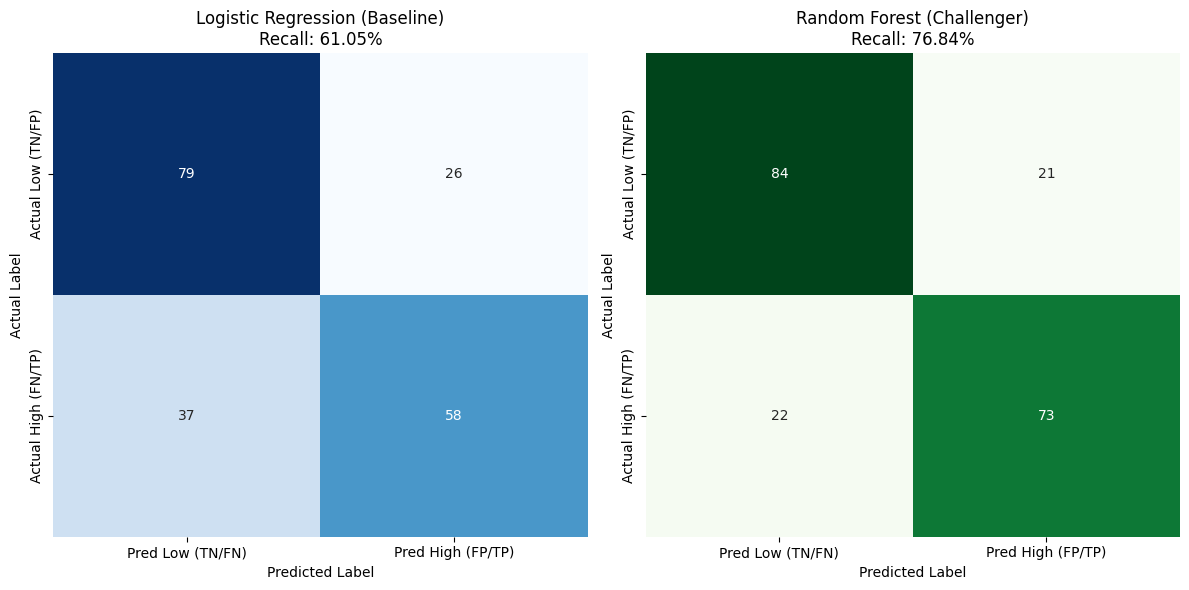

In [12]:
# ai helped 

# Compute the matrices
conMatrix_logisticReg = confusion_matrix(y_test, logistic_regression_predict)
conMatric_RandFrst = confusion_matrix(y_test, random_forest_predict)

# Plotting dimesntions
fig, axes = plt.subplots(1,2, figsize=(12, 6))

# Logistic Regression heatmap
sns.heatmap(
    conMatrix_logisticReg,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
    xticklabels=["Pred Low (TN/FN)", "Pred High (FP/TP)"],
    yticklabels=["Actual Low (TN/FP)", "Actual High (FN/TP)"],
)
axes[0].set_title("Logistic Regression (Baseline)\nRecall: 61.05%", fontsize=12)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# Random Forest heatmap
sns.heatmap(
    conMatric_RandFrst,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    ax=axes[1],
    xticklabels=["Pred Low (TN/FN)", "Pred High (FP/TP)"],
    yticklabels=["Actual Low (TN/FP)", "Actual High (FN/TP)"]
)
axes[1].set_title("Random Forest (Challenger)\nRecall: 76.84%", fontsize=12)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()



H3 is partially supported. Immediate physical traits house strong predictive features, enabling Random Forest to outperform the linear baseline by over 15% in Recall, 76.84 vs 61.05%. 

However, these real-time parameters are insufficient in isolation to meet the required 85% Recall threshold. Localised intensity is dependant on other spatial and environmental factors, which will require additional and feature engineering to test and inspect further.

---

# Conclusion

H1 - Earthquake magnitude and focal depth operate as statistically independent features, meaning focal depth cannot serve as an indicator of magnitude when classifying high-severity.

* The tested p-value of 0.8516 shows that magnitude and depth indeed operate as independant features meaning the raw output of an earthquake has nothing to do with the depth it was generated, resulting in not being suitable for classifying high severity events.



H2 - Earthquakes that generate a tsunami occur at significantly lower focal depths and are triggered by specific fault mechanisms (magType), as apposed to ones that don't.

* Likewise with H1, depth had no bearing on the outcome of a tsunami. However the magType was higly significant witha p-value of 0.0001. Exploring the relationship between magType's and other spatial/physical variables would be the next logical step for refining tsunami generation classification. 